# analyses of the digit span task data from the delay condition

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_1samp

from collections import Counter


In [16]:
# load
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/all_digit_span.csv").copy()

In [8]:
df.columns

Index(['uid', 'session', 'trial_num', 'sequence_length', 'presented_sequence',
       'participant_response', 'response_time_ms', 'timestamp', 'study_result',
       'comp_result'],
      dtype='object')

In [25]:
df

,uid,session,trial_num,presented_sequence,participant_response,response_time_ms,timestamp,study_result,comp_result
0,9o7z7o4e1772730936282,1,1,47528,47528,9662,1772731856210,study_result_1046706,comp-result_1414591
1,9o7z7o4e1772730936282,1,2,45496020,4546902,12832,1772731869046,study_result_1046706,comp-result_1414591
2,9o7z7o4e1772730936282,1,3,34,34,5883,1772731874930,study_result_1046706,comp-result_1414591
3,9o7z7o4e1772730936282,1,4,4836,4836,104034,1772731978965,study_result_1046706,comp-result_1414591
4,9o7z7o4e1772730936282,1,5,354741,354741,10281,1772731989247,study_result_1046706,comp-result_1414591
...,...,...,...,...,...,...,...,...,...
591,puqz4woy1773084496016,5,24,235,2350,9226,1773088727070,study_result_1048791,comp-result_1417286
592,puqz4woy1773084496016,5,25,69835,69835,10541,1773088737612,study_result_1048791,comp-result_1417286
593,puqz4woy1773084496016,5,26,89652,89652,10477,1773088748089,study_result_1048791,comp-result_1417286
594,puqz4woy1773084496016,5,27,16905,16905,10103,1773088758192,study_result_1048791,comp-result_1417286


In [24]:
df[df['uid'] == "uv0vccs51773064211294"]

,uid,session,trial_num,presented_sequence,participant_response,response_time_ms,timestamp,study_result,comp_result
84,uv0vccs51773064211294,1,1,285,285.0,8187,1773064701994,study_result_1048479,comp-result_1416896
85,uv0vccs51773064211294,1,2,932,932.0,7877,1773064709871,study_result_1048479,comp-result_1416896
86,uv0vccs51773064211294,1,3,6345,635.0,39420,1773064749291,study_result_1048479,comp-result_1416896
87,uv0vccs51773064211294,1,4,701,701.0,9506,1773064758798,study_result_1048479,comp-result_1416896
88,uv0vccs51773064211294,1,5,6737451,6737451.0,33549,1773064792346,study_result_1048479,comp-result_1416896
...,...,...,...,...,...,...,...,...,...
143,uv0vccs51773064211294,5,12,283743686,28374689.0,41729,1773068006228,study_result_1048479,comp-result_1416896
144,uv0vccs51773064211294,5,13,46706736,4670673.0,23221,1773068029449,study_result_1048479,comp-result_1416896
145,uv0vccs51773064211294,5,14,919,919.0,7962,1773068037411,study_result_1048479,comp-result_1416896
146,uv0vccs51773064211294,5,15,52873,52873.0,10696,1773068048108,study_result_1048479,comp-result_1416896


In [ ]:
# sequence length was calculated in a wrong way...
df = df.drop('sequence_length', axis=1)

In [26]:
#adding columns summarizing the success of participants
# 1. Helper functions for scoring

def clean_float_response(x):
    if pd.isna(x) or x == "":
        return ""
    try:
        # Convert to float first, then check if it's a whole number
        f_val = float(x)
        if f_val == int(f_val):
            return str(int(f_val)) # 123.0 -> "123"
        return str(f_val)
    except (ValueError, TypeError):
        return str(x) # Keep as string if it's text (e.g., "unknown")

# Apply this to your column
df['participant_response'] = df['participant_response'].apply(clean_float_response)

def calculate_order_accuracy(row):
    """Counts digits correct in the exact positional order."""
    pres = str(row['presented_sequence'])
    resp = str(row['participant_response'])
    # Compare position by position
    matches = sum(1 for p, r in zip(pres, resp) if p == r)
    return matches

def calculate_set_accuracy(row):
    """Counts digits correct regardless of order (multiset intersection)."""
    pres = Counter(str(row['presented_sequence']))
    resp = Counter(str(row['participant_response']))
    intersection = pres & resp
    return sum(intersection.values())

# 2. Main Processing
def analyze_digit_span(df):
    # Data Cleaning: Handle NaNs and ensure string types for comparison
    df = df.copy()
    df['presented_sequence'] = df['presented_sequence'].astype(str)
    df['participant_response'] = df['participant_response'].astype(str).replace('nan', '')
    df['sequence_length'] = df['presented_sequence'].apply(lambda x: len(str(x))) # a new correct measure
    # METRIC A: Exact Match (100% Correct)
    df['is_exact_match'] = (df['presented_sequence'] == df['participant_response']).astype(int)
    
    # METRIC B: Exact Order Accuracy
    df['correct_order_count'] = df.apply(calculate_order_accuracy, axis=1)
    df['order_acc_pct'] = df['correct_order_count'] / df['sequence_length']
    
    # METRIC C: Overall Digit Accuracy (regardless of order)
    df['correct_total_count'] = df.apply(calculate_set_accuracy, axis=1)
    df['total_acc_pct'] = df['correct_total_count'] / df['sequence_length']
    
    return df

# Apply analysis
df_analyzed = analyze_digit_span(df)


In [27]:
df_analyzed.head()

,uid,session,trial_num,presented_sequence,participant_response,response_time_ms,timestamp,study_result,comp_result,sequence_length,is_exact_match,correct_order_count,order_acc_pct,correct_total_count,total_acc_pct
0,9o7z7o4e1772730936282,1,1,47528,47528,9662,1772731856210,study_result_1046706,comp-result_1414591,5,1,5,1.000,5,1.000
1,9o7z7o4e1772730936282,1,2,45496020,4546902,12832,1772731869046,study_result_1046706,comp-result_1414591,8,0,5,0.625,7,0.875
2,9o7z7o4e1772730936282,1,3,34,34,5883,1772731874930,study_result_1046706,comp-result_1414591,2,1,2,1.000,2,1.000
3,9o7z7o4e1772730936282,1,4,4836,4836,104034,1772731978965,study_result_1046706,comp-result_1414591,4,1,4,1.000,4,1.000
4,9o7z7o4e1772730936282,1,5,354741,354741,10281,1772731989247,study_result_1046706,comp-result_1414591,6,1,6,1.000,6,1.000


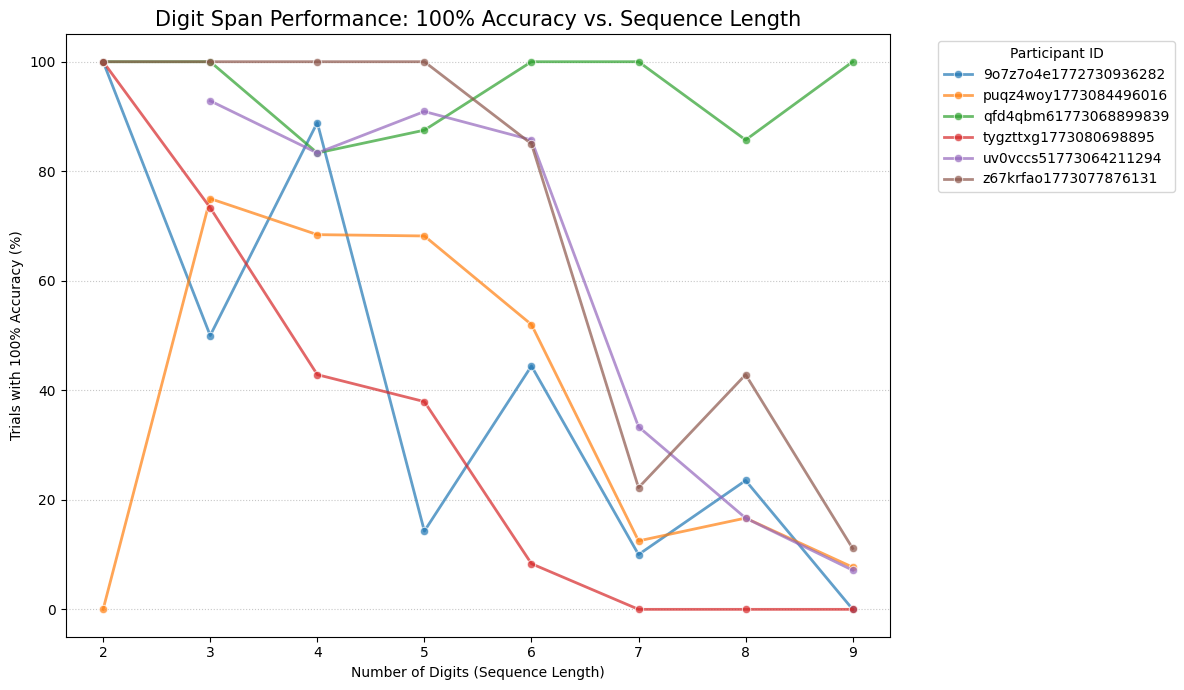

In [31]:

# 3. Aggregation: Per Session
session_summary = df_analyzed.groupby(['uid', 'session']).agg(
    trial_count=('trial_num', 'count'),
    exact_match_pct=('is_exact_match', 'mean'),
    order_acc_mean=('order_acc_pct', 'mean'),
    total_acc_mean=('total_acc_pct', 'mean')
).reset_index()

# 4. Aggregation: Per Participant (Across all 5 sessions)
participant_summary = df_analyzed.groupby('uid').agg(
    avg_exact_match=('is_exact_match', 'mean'),
    avg_positional_acc=('order_acc_pct', 'mean'),
    avg_digit_recall=('total_acc_pct', 'mean')
).reset_index()

# 5. Visualization: Performance by Sequence Length
# This shows the "Span Limit" per participant
viz_data = df_analyzed.groupby(['uid', 'sequence_length'])['is_exact_match'].mean().reset_index()
viz_data['percentage_correct'] = viz_data['is_exact_match'] * 100

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=viz_data, 
    x='sequence_length', 
    y='percentage_correct', 
    hue='uid', 
    marker='o', 
    linewidth=2,
    alpha=0.7
)


plt.title('Digit Span Performance: 100% Accuracy vs. Sequence Length', fontsize=15)
plt.ylabel('Trials with 100% Accuracy (%)')
plt.xlabel('Number of Digits (Sequence Length)')
plt.xticks(range(2, 10))
plt.legend(title='Participant ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('digit_span_load_analysis.png')

# Save outputs
df_analyzed.to_csv('digit_span_processed.csv', index=False)
session_summary.to_csv('digit_span_session_summary.csv', index=False)

In [29]:
participant_summary

,uid,avg_exact_match,avg_positional_acc,avg_digit_recall
0,9o7z7o4e1772730936282,0.309524,0.512283,0.737415
1,puqz4woy1773084496016,0.458333,0.736561,0.914997
2,qfd4qbm61773068899839,0.945455,0.978636,0.985909
3,tygzttxg1773080698895,0.215190,0.523764,0.729199
4,uv0vccs51773064211294,0.593750,0.799963,0.916326
5,z67krfao1773077876131,0.739130,0.875673,0.960145
